**Building a Churn Prediction Model**

What we're doing: Using the RFM scores to predict whether a customer will churn (stop buying). We'll label customers as:
Churned = 1 → Recency > 180 days (haven't bought in 6 months)
Active = 0 → Recency ≤ 180 days 

In [1]:
# Import libraries for data manipulation, visualization, preprocessing, model training, and evaluation

# Data handling and numerical computations
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split, GridSearchCV

# Logistic Regression classification model
from sklearn.linear_model import LogisticRegression

# Feature scaling to standardize numerical variables
from sklearn.preprocessing import StandardScaler

# Model evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load the UK retail dataset and automatically convert InvoiceDate to datetime format
df = pd.read_csv("Data/uk_retail.csv", parse_dates=["InvoiceDate"])

# Display the number of rows and columns in the dataset
print(df.shape)

(725296, 10)


In [3]:
# Define a cutoff date to separate historical and future transactions
split_date = pd.Timestamp("2011-06-01")

# Create a dataset containing transactions before the cutoff date
past = df[df["InvoiceDate"] < split_date]

# Create a dataset containing transactions on or after the cutoff date
future = df[df["InvoiceDate"] >= split_date]

# Display the number of records in each dataset
print("Past rows:", past.shape[0])
print("Future rows:", future.shape[0])

Past rows: 500897
Future rows: 224399


In [4]:
# Set the reference date as the cutoff date for RFM calculations
reference_date = split_date

# Calculate RFM metrics for each customer using historical transactions
rfm = past.groupby("Customer ID").agg(
    # Days since the customer's last purchase before the cutoff date
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),

    # Number of unique orders placed by the customer
    Frequency=("Invoice", "nunique"),

    # Total revenue generated by the customer
    Monetary=("Revenue", "sum")
).reset_index()

# Display the size of the RFM dataset
print(rfm.shape)

# Preview the first few customer records
print(rfm.head())

(4520, 4)
   Customer ID  Recency  Frequency  Monetary
0      12346.0      133         12  77556.46
1      12608.0      212          1    415.79
2      12745.0      294          2    723.85
3      12746.0      348          1    254.55
4      12747.0        6         21   7171.93


In [5]:
# Calculate the average revenue generated per order
rfm["Revenue_per_Order"] = rfm["Monetary"] / rfm["Frequency"]

# Identify customers who made only one purchase
rfm["Is_OneTime_Buyer"] = (rfm["Frequency"] == 1).astype(int)

# Calculate the percentile rank of each customer's spending
rfm["Monetary_Rank"] = rfm["Monetary"].rank(pct=True)

# Calculate the percentile rank of each customer's purchase frequency
rfm["Frequency_Rank"] = rfm["Frequency"].rank(pct=True)

# Flag customers whose spending is in the top 25%
rfm["High_Value"] = (
    rfm["Monetary"] > rfm["Monetary"].quantile(0.75)
).astype(int)

# Apply log transformation to reduce skewness in Frequency
rfm["Log_Frequency"] = np.log1p(rfm["Frequency"])

# Apply log transformation to reduce skewness in Monetary
rfm["Log_Monetary"] = np.log1p(rfm["Monetary"])

# Display all available columns
print(rfm.columns.tolist())

['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Revenue_per_Order', 'Is_OneTime_Buyer', 'Monetary_Rank', 'Frequency_Rank', 'High_Value', 'Log_Frequency', 'Log_Monetary']


In [6]:
future_customers = set(future["Customer ID"].unique())

rfm["Churned"] = rfm["Customer ID"].apply(
    lambda x: 0 if x in future_customers else 1
)

print(rfm["Churned"].value_counts())

Churned
0    2377
1    2143
Name: count, dtype: int64


In [7]:
X = rfm[["Recency", "Frequency", "Monetary",
          "Revenue_per_Order", "Is_OneTime_Buyer",
          "Monetary_Rank", "Frequency_Rank",
          "High_Value", "Log_Frequency", "Log_Monetary"]]

y = rfm["Churned"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4520, 10)
y shape: (4520,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3616, 10)
Test size: (904, 10)


In [9]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [200, 500, 1000]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV accuracy:", f"{grid.best_score_:.2%}")

Best params: {'C': 1, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV accuracy: 72.32%


In [10]:
y_pred = best_model.predict(X_test_scaled)

print("Test accuracy:", f"{accuracy_score(y_test, y_pred):.2%}")
print("\n", classification_report(y_test, y_pred))

Test accuracy: 70.91%

               precision    recall  f1-score   support

           0       0.73      0.71      0.72       482
           1       0.68      0.71      0.69       422

    accuracy                           0.71       904
   macro avg       0.71      0.71      0.71       904
weighted avg       0.71      0.71      0.71       904



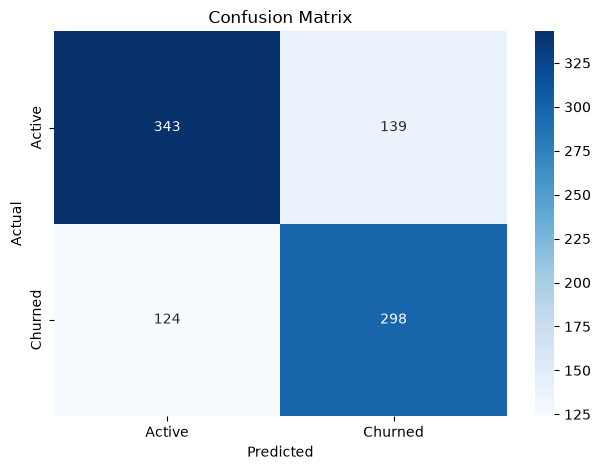

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Features: 10
Coefficients: 10


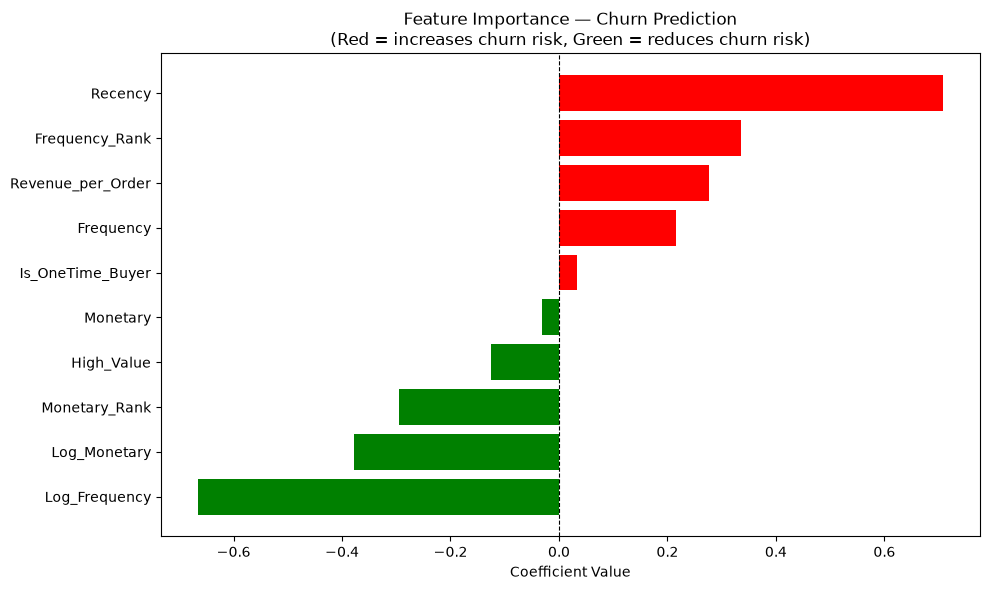

In [12]:
feature_names = X.columns.tolist()
coefficients = best_model.coef_[0]

print("Features:", len(feature_names))
print("Coefficients:", len(coefficients))

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=True)

colors = ["red" if c > 0 else "green" for c in importance_df["Coefficient"]]

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
plt.title("Feature Importance — Churn Prediction\n(Red = increases churn risk, Green = reduces churn risk)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

In [13]:
# Add predictions to rfm table
rfm["Churn_Predicted"] = best_model.predict(scaler.transform(X))
rfm["Churn_Probability"] = best_model.predict_proba(scaler.transform(X))[:, 1]

# Add segment labels back
def segment_customer(row):
    r_score = pd.qcut([row["Recency"]], q=5, labels=[5,4,3,2,1])[0]
    return r_score

# Simpler - just save rfm with predictions
dashboard_df = rfm.copy()
dashboard_df.to_csv("Data/dashboard_data.csv", index=False)
print("Saved!")
print(dashboard_df.columns.tolist())

Saved!
['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Revenue_per_Order', 'Is_OneTime_Buyer', 'Monetary_Rank', 'Frequency_Rank', 'High_Value', 'Log_Frequency', 'Log_Monetary', 'Churned', 'Churn_Predicted', 'Churn_Probability']
